# The Weekend Oracle \U0001F52E
### Bitcoin trades while Wall Street sleeps. Does it know something about Monday?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

Every Friday at four o'clock the stock market shuts for sixty-five hours. Bitcoin does not.
Whatever the world learns over a weekend is priced by one of them and cannot be priced by the
other — which makes this the cleanest lead-lag experiment available anywhere in markets.

> \U0001F4D3 **This is the plain-language layer.** The overlap accounting, the regime splits and
> the falsification control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the usual "crypto leads stocks" chart prove anything? | No — the two closes are three hours apart and the chart is measuring the clock. |
| Is there a clean version of the question? | Yes: the weekend, when equities cannot trade at all. |
| Does the weekend move predict the next session? | See the regression below — and note the R². |
| Would you trade it? | See the last section, where it is benchmarked against the same sessions held blind. |

## 1 · The trick the clock plays

Yahoo's Bitcoin daily bar runs midnight to midnight **UTC**. The New York close is at about
**21:00 UTC**. So Bitcoin's "Monday" bar contains three hours of Monday evening that the
American stock market never saw.

That is why "Bitcoin's move today is correlated with stocks tomorrow" is not evidence of
anything: part of "today" for Bitcoin is already "tomorrow" for stocks.

In [2]:
from weekendoracle import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
eq_px = px[data.EQUITY].dropna()
eq_rets = eq_px.pct_change()
cash_rets = rets[data.CASH].reindex(eq_px.index).fillna(0.0)
panel = st.attach_target(st.weekend_returns(px[data.CRYPTO].dropna(), eq_px.index), eq_rets)
print(f"as-of {data.AS_OF} | {len(panel):,} closed-market windows, "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
print(panel.head().to_string())

as-of 2026-06-30 | 646 closed-market windows, 2014-09-22 -> 2026-06-29
           previous_session  gap_days  crypto_return  equity_return
session                                                            
2014-09-22       2014-09-19         3         0.0186        -0.0077
2014-09-29       2014-09-26         3        -0.0716        -0.0018
2014-10-06       2014-10-03         3        -0.0819        -0.0012
2014-10-13       2014-10-10         3         0.0798        -0.0164
2014-10-20       2014-10-17         3        -0.0024         0.0097


## 2 · The one clean window

Sixty-five hours a week, one market is open and the other is shut. There is no overlap to argue
about.

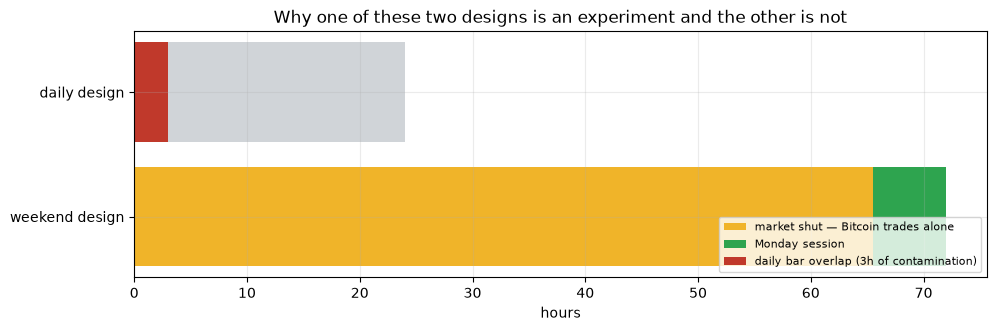

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.barh([0], [65.5], left=[0], color="#f0b429", label="market shut — Bitcoin trades alone")
ax.barh([0], [6.5], left=[65.5], color="#2ea44f", label="Monday session")
ax.barh([1], [3], left=[0], color="#c0392b", label="daily bar overlap (3h of contamination)")
ax.barh([1], [21], left=[3], color="#8b949e", alpha=0.4)
ax.set_yticks([0, 1]); ax.set_yticklabels(["weekend design", "daily design"])
ax.set_xlabel("hours"); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Why one of these two designs is an experiment and the other is not")
plt.show()

## 3 · What the weekend actually says about Monday

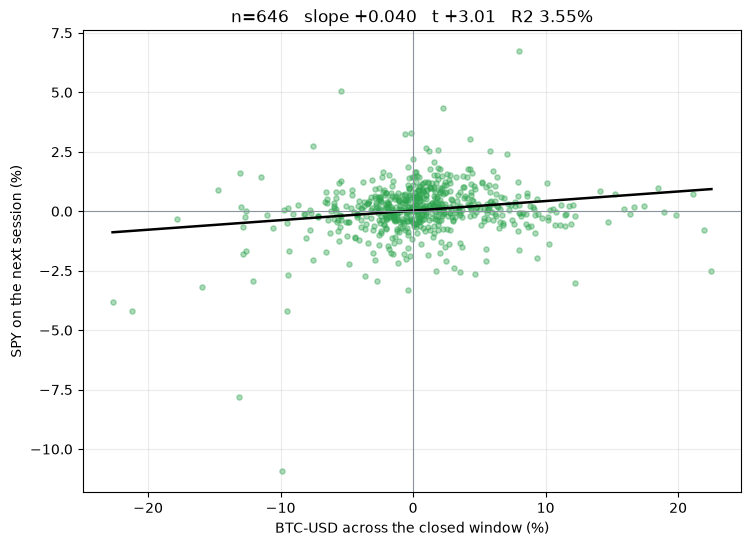

                       n    mean  median     sd      t
bucket                                                
crypto weekend up    363  0.0024  0.0019 0.0095    NaN
crypto weekend down  283 -0.0019 -0.0003 0.0131    NaN
difference           646  0.0043     NaN    NaN 4.6361


In [4]:
reg = st.monday_regression(panel)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(panel["crypto_return"] * 100, panel["equity_return"] * 100, s=14, alpha=0.4,
           color="#2ea44f")
xs = np.linspace(panel["crypto_return"].min(), panel["crypto_return"].max(), 50)
ax.plot(xs * 100, (reg["alpha"] + reg["beta"] * xs) * 100, color="k", lw=1.8)
ax.axhline(0, color="#8b949e", lw=0.8); ax.axvline(0, color="#8b949e", lw=0.8)
ax.set_xlabel(f"{data.CRYPTO} across the closed window (%)")
ax.set_ylabel(f"{data.EQUITY} on the next session (%)")
ax.set_title(f"n={reg['n']}   slope {reg['beta']:+.3f}   t {reg['t']:+.2f}   "
             f"R2 {reg['r2']:.2%}")
plt.show()
print(st.conditional_means(panel).round(5).to_string())

> \U0001F52C **For the quants.** Look at the R² before the *t*. A slope can be statistically
> distinguishable from zero and still explain almost none of Monday — those are two different
> claims and traders routinely collapse them.

### A caveat that has to come *before* the answer, not after

Bitcoin's weekend move is a **noisy proxy** for the weekend's news. Most of a 4-5% weekend swing
is Bitcoin's own business — liquidations, a listing, a tweet — and has nothing to do with what
equities will price on Monday. That noise caps how strong a relationship this test can ever
show, whatever the truth is.

In [5]:
sd = panel["crypto_return"].std()
c = st.detectability_ceiling(len(panel), crypto_noise=sd)
print(f"Bitcoin's weekend move: sd {sd:.1%}")
print(f"Largest |t| this experiment could ever produce over {len(panel)} weekends: "
      f"{c['max_t']:.2f}")
print(f"Weekends that would be needed to see it reliably: ~{c['n_weeks_for_t2']:.0f} "
      f"({c['n_weeks_for_t2'] / 52:.0f} years)")
print(f"Weekends available: {len(panel)} ({len(panel) / 52:.0f} years)")

Bitcoin's weekend move: sd 5.3%
Largest |t| this experiment could ever produce over 646 weekends: 2.84
Weekends that would be needed to see it reliably: ~321 (6 years)
Weekends available: 646 (12 years)


So if the number below is small, the right conclusion is *"we cannot tell"*, not *"there is
nothing there"*. That distinction is the difference between a result and a shrug, and most
write-ups of this question skip it.

## 4 · Before and after Bitcoin grew up

                     n   beta      t     r2
regime                                     
before 2020-03-01  300 0.0015 0.0982 0.0001
since 2020-03-01   346 0.0856 3.9668 0.1078


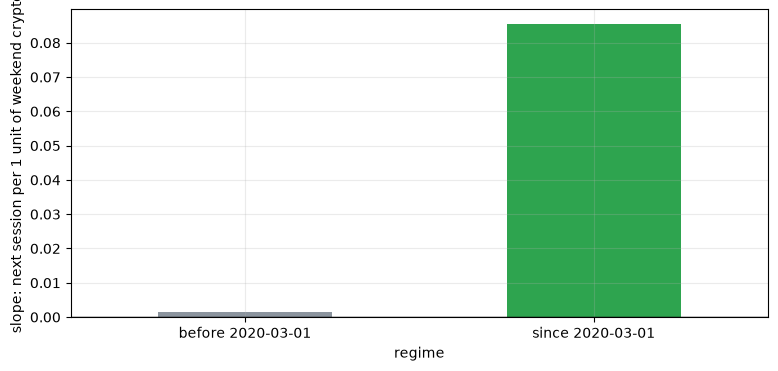

In [6]:
rs = st.regime_split(panel)
print(rs.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4))
rs["beta"].plot.bar(ax=ax, color=["#8b949e", "#2ea44f"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("slope: next session per 1 unit of weekend crypto")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()

## 5 · The gold control

GLD is shut over the weekend too. Its "weekend return" is measured across a window in which it
did not trade — so it must show nothing. If it shows something, the machine is broken.

In [7]:
for label, tk in (("Bitcoin", data.CRYPTO), ("Ethereum", data.CRYPTO_2),
                  ("Gold (control)", data.GOLD)):
    s = px[tk].dropna()
    p = st.attach_target(st.weekend_returns(s, eq_px.index), eq_rets)
    r = st.monday_regression(p)
    print(f"{label:16s} n {r['n']:4d}  slope {r['beta']:+.4f}  t {r['t']:+.2f}  "
          f"R2 {r['r2']:.2%}")

Bitcoin          n  646  slope +0.0402  t +3.01  R2 3.55%


Ethereum         n  476  slope +0.0422  t +3.06  R2 6.26%


Gold (control)   n 1181  slope +0.0207  t +0.35  R2 0.03%


## 6 · The verdict

**Signal: Real.** Over 646 closed-market windows (2014-09-22 → 2026-06-29), a 1% Bitcoin move across the weekend was followed by a **+4.019%** move in SPY on the next session (*t* = **+3.01**, R² 3.55%). The sign agreed 58.8% of the time against a 50% coin flip (*t* = +4.49), and the average next-session return was +0.242% after an up weekend against -0.187% after a down one (*t* = +4.64). Split at March 2020 the slope was +0.001 before and +0.086 after — the era in which Bitcoin became a high-beta Nasdaq position is doing most of the work. This is the **clean** design: zero hours of overlap, unlike the ordinary daily lead-lag correlation of -0.01, which shares 3 hours of clock with its own target. One thing this stamp must not be read as: Bitcoin's weekend move has a standard deviation of 5.3%, most of it Bitcoin's own business, so even a weekend whose news determined Monday perfectly could only produce a *t* of about **2.8** over 646 windows — a null here is weak evidence of absence, not strong evidence of nothing.

**Tradability: Fragile.** Buying SPY only on the session after an up crypto weekend — 363 of 646 windows, 56% of them — returned **+6.28%/yr** on those same sessions against **+2.64%** for holding every one of them regardless (+3.64%/yr, *t* = +1.72), after 2 bps a side. The rule is in the market about one session a week, so this is a comparison of like with like, not a Sharpe you can put next to a buy-and-hold Sharpe.

## 7 · Going further \U0001F6AA

- **Use the Monday open**, not the Monday close. If the weekend news is priced in the first
  minutes, close-to-close hides it.
- **The overnight window on ordinary days** is the same idea thirteen hours long and five times
  a week — but it needs intraday data, because of the clock problem in section 1.
- **Macro weekends specifically**: closures containing an election, an OPEC meeting or a
  banking failure are where the effect, if any, should concentrate.